# Jev against frontier LLMs and a trained SVM

Phase 2 of `jev-experiment-plan.md`. Jev, three frontier LLMs and a TF-IDF + linear SVM classify
the same rows from three datasets: Banking77 (77 intents), AG News (4 topics) and IMDb (2
sentiments). Jev and each LLM run twice, zero-shot and few-shot. The SVM is trained once per
dataset. The metric is balanced accuracy (the mean of per-class recall).

**Sample size.** `N_TEST` in the first code cell sets the number of test rows per dataset. It is 1,000
for the full run, about 13 rows per Banking77 class. With fewer rows a balanced accuracy is unstable, and Banking77 has 77 classes, so a small
sample covers only some of them. The tables and the chart therefore show 95% bootstrap intervals,
and section 6 compares models on the same rows. Each condition is run once.

**Running it.** The run in section 4 is expected to take about 7 hours at 1,000 rows. Jev alone needs about 4.3 hours,
because the gateway limits it to 30 requests a minute (section 1). That is far longer than nbconvert's default 30-second limit per
cell, so switch the limit off:

```
uv run jupyter nbconvert --execute --to notebook --inplace --ExecutePreprocessor.timeout=-1 notebooks/02_jev_vs_llms_benchmark.ipynb
```

Sections:

1. Setup and choices made before running
2. Data: official splits, samples and few-shot examples
3. Checks before the full run
4. Running the API models
5. Running the SVM
6. Accuracy
7. IMDb with a fitted threshold
8. Cost and latency
9. Files and how to read the results

## 1. Setup and choices made before running

Where the plan left a question open, or was changed, these are the choices used here.

- **LLM output is a label plus a confidence.** The plan describes label-only output. Phase 3 needs
  each LLM's own confidence, so all three LLMs return both, in both shot conditions, and the table
  stays like for like. `confidence` is the model's estimate, from 0 to 1, that its label is right.
  Adding the field may change some labels compared with label-only output. That was not tested.
- **Jev is asked one `choice` question per row.** The criteria are the shared label descriptions.
  Jev returns a probability for every label and a `confidence`.
- **Failures.** A transient failure (rate limit, server error, timeout, connection error) is retried
  after the wait the server asks for, or with a growing backoff if it does not say, up to eight
  attempts. A failure that remains is stored on the row with its kind.
  Balanced accuracy is shown twice: on the rows that got an answer, and with every failed row
  counted as wrong. Failures are split into model behaviour (unusable output, refusal, input too
  long) and infrastructure (rate limits, network, and any error that is not an API failure, which is
  stored as `unexpected`). Infrastructure failures left after retries mean the run should be
  repeated.
- **Early stop.** A condition stops with an error if its first twenty rows show a systematic fault:
  a rejected key or model ID, or more than a quarter of those rows failing after retries. Its file
  then holds fewer rows than the sample, and the run should be repeated after the fault is fixed.
- **One run per condition.** Nothing is repeated, so there is no measure of run-to-run variation.
  Temperature is 0 where the API allows it (Haiku and Gemini). A temperature of 0 is not always
  advisable for Gemini models, so Gemini was tried on 60 train rows (30 each from
  Banking77 and AG News) with and without the setting. Both gave the same labels, with no failures
  and no runaway output, so the setting stays. The OpenAI model has its own reasoning setting and no
  temperature control, and Jev has none. No response is cached.
- **Few-shot examples.** One per class, from a single random draw from the official train split,
  using texts of up to 1,200 characters so that one long IMDb review does not dominate the prompt.
  The examples are shuffled once with a fixed seed, so the example next to the text is not always
  the same class. Every model sees the same examples in the same order and format. The draw is made
  once, so a few-shot score depends partly on which examples were drawn, and that spread is not
  measured.
- **Zero-shot calls never see train.** They receive only the row's text and the shared label
  descriptions. Train is used for the few-shot examples, the SVM, and the IMDb threshold carve-out.
  The live checks in section 3 use train rows, so the test sample is used only for scoring.
- **Prompt caching.** Every row is a fresh model call and no response is reused. What is reused
  is the provider's processing of the start of the prompt that is the same for every row (the
  system prompt and, in the few-shot condition, the examples). The row's own text comes last so
  that this start can be cached. Anthropic needs an explicit cache marker and only caches from
  4,096 tokens on Haiku 4.5. OpenAI caches automatically from 1,024 tokens. Gemini's automatic
  caching gave no hits in a trial, so its cache is created explicitly, once per prompt, and
  deleted after the run. The first row of each condition runs alone to fill the cache before the
  rest run in parallel. Short prompts are not cached, so the saving is mostly on Banking77. Jev
  has no cache setting. Cached tokens are priced at each provider's cache price (section 8).
- **Gemini thinking.** `gemini-3.8-flash` does not accept a setting that turns thinking off
  (`thinking_budget: 0` still produced up to about 70 thinking tokens on some rows, and `minimal`
  is rejected). Its thinking tokens are counted as output tokens in the cost. This is a small
  departure from "no reasoning" for the Gemini column.
- **Latency** is the time of the successful call only. It is measured with several requests in
  flight (`WORKERS`), so it can be slightly higher than for one request at a time. Jev is called
  through the Vercel AI Gateway and the LLMs directly, so their latencies differ by route as well as
  by model. The gateway limits Jev to 30 requests a minute (its 429 responses say so), so Jev's requests are
  paced at 27 a minute (`requests_per_minute` in `configs/models.json`). Jev's throughput is
  therefore a limit of this account, not a property of Jev: 7,000 requests take about 4.3 hours
  whatever `WORKERS` is. Section 8 also gives the time per row including failed attempts and waits
  (`wall`), which for Jev includes the wait for the pacer, and the share of rows that were retried.
- **Traceability.** Each results file records hashes of the code, the label file and
  `configs/models.json`, the package versions and the git state. `results/run_manifest.json` holds
  the settings and a hash of each dataset split. The label descriptions were fixed before the run and
  must not be edited after results have been seen.
- **Public data.** All three datasets are public, so every model here, Jev included, may have seen
  them in training. The scores show performance on tasks the models may know, not on new data.

In [ ]:
import json
import os
import time
from datetime import date

import pandas as pd

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

from jev_compare import bench, data, llm

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

# ---- run settings -------------------------------------------------------------------------
N_TEST = 1000  # rows per dataset, sampled from the official test split
N_THRESHOLD = 500  # IMDb rows carved out of train to fit the decision threshold
SEED = 0
WORKERS = 4  # requests in flight at once
SHOTS = ("zeroshot", "fewshot")
DATASETS = data.DATASETS
# --------------------------------------------------------------------------------------------

ROOT = data.ROOT
RESULTS = bench.RESULTS
RESULTS.mkdir(exist_ok=True)
CONFIG = json.loads((ROOT / "configs" / "models.json").read_text(encoding="utf-8"))
MODELS = CONFIG["models"]
RUN_DATE = date.today().isoformat()
print("run date:", RUN_DATE)

Each model needs its API key (names are in `.env.example`) and a model ID the provider recognises.
A model that fails either check is left out of the run and marked "not run" in the tables, with the
reason shown here. It is not counted as wrong.

In [2]:
ACTIVE, SKIPPED = {}, {}
for key, cfg in MODELS.items():
    if not llm.has_key(cfg):
        SKIPPED[key] = f"{cfg.get('env_key', 'AI_GATEWAY_API_KEY')} is not set"
        continue
    ok, msg = llm.check_model_id(cfg)
    if ok:
        ACTIVE[key] = cfg
    else:
        SKIPPED[key] = f"model ID {cfg['model_id']!r} was not accepted: {msg}"

pd.DataFrame(
    [
        {
            "model": key,
            "model ID": cfg["model_id"],
            "status": "will run" if key in ACTIVE else "not run",
            "detail": SKIPPED.get(key, ""),
        }
        for key, cfg in MODELS.items()
    ]
).set_index("model")

,model ID,status,detail
model,,,
jev,typesafe-ai/jev,will run,
haiku,claude-haiku-4-5,will run,
openai,gpt-5.4-mini,will run,
gemini,gemini-3.8-flash,will run,


## 2. Data: official splits, samples and few-shot examples

The evaluation set is a stratified sample of the official test split of each dataset. Classes get
equal shares as far as possible, and the sample is the same for every model. Few-shot examples and
the SVM's training data come from the official train split. For IMDb, a separate stratified chunk of
train (disjoint from the few-shot examples) is set aside to fit the decision threshold in section 7.
That chunk is a carve-out made for this project. It is not a published validation split, and none of
these datasets has one.

Each sample is saved to `results/sample_<dataset>.csv` before any model runs. `row_id` is the row's
position in the official split.

In [ ]:
DATA = {}
overview = []
manifest = {
    "run_date": RUN_DATE,
    "settings": {
        "N_TEST": N_TEST,
        "N_THRESHOLD": N_THRESHOLD,
        "SEED": SEED,
        "WORKERS": WORKERS,
        "SHOTS": list(SHOTS),
    },
    "datasets": {},
}
for ds in DATASETS:
    labels = data.load_labels(ds)
    train, test = data.load_splits(ds)
    sample = data.stratified_sample(test, N_TEST, SEED)
    pool = data.few_shot_pool(train, SEED + 1)
    carve = None
    if ds == "imdb":
        carve = data.threshold_carveout(train, N_THRESHOLD, SEED + 2, set(pool.row_id))
        assert not set(carve.row_id) & set(pool.row_id)
        carve.to_csv(RESULTS / "threshold_carveout_imdb.csv", index=False)

    # The sample must be rows of the official test split, unchanged.
    official_text = test.set_index("row_id").loc[sample.row_id, "text"].to_numpy()
    assert (official_text == sample.text.to_numpy()).all()
    sample.to_csv(RESULTS / f"sample_{ds}.csv", index=False)
    pool.to_csv(RESULTS / f"fewshot_{ds}.csv", index=False)

    DATA[ds] = {
        "labels": labels,
        "train": train,
        "test": test,
        "sample": sample,
        "pool": pool,
        "examples": list(zip(pool.text, pool.label, strict=True)),
        "carve": carve,
    }
    manifest["datasets"][ds] = {
        "train_sha256": data.fingerprint(train),
        "test_sha256": data.fingerprint(test),
        "sample_sha256": data.fingerprint(sample),
        **bench.provenance(ds),
    }
    overview.append(
        {
            "dataset": ds,
            "classes": len(labels.labels),
            "official train": len(train),
            "official test": len(test),
            "test sample": len(sample),
            "classes in sample": sample.label.nunique(),
            "few-shot examples": len(pool),
        }
    )
(RESULTS / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
pd.DataFrame(overview).set_index("dataset")

The label descriptions live in `configs/labels/<dataset>.json`. The same file supplies Jev's `choice`
criteria and the label list in the LLMs' system prompt, so no model gets a better-written label set.
The next cell shows the LLM system prompt for AG News, and the state that every model receives for
one row in each shot condition (the few-shot state is cut short here for space).

In [4]:
ag = DATA["ag_news"]
print(llm.system_prompt(ag["labels"]))
row_text = ag["sample"].text[0]
print("\n" + "=" * 70 + "\nZERO-SHOT state:\n" + bench.build_state(row_text, None))
few = bench.build_state(row_text, ag["examples"])
print("\n" + "=" * 70 + "\nFEW-SHOT state (first 900 characters):\n" + few[:900] + " ...")

Classify the news article by its main topic. Choose the single topic that best describes the article.

Labels:
- World: International news: politics, government, conflicts, diplomacy and events in or between countries.
- Sports: Sport: matches, players, teams, tournaments, results and transfers.
- Business: Business and economics: companies, markets, earnings, trade, prices, jobs and finance.
- Sci/Tech: Science and technology: research, space, health science, computing, the internet, software, gadgets and telecoms.

Reply with JSON containing `label` (exactly one of the labels above) and `confidence` (a number from 0 to 1: your estimate of the probability that the label is correct).

ZERO-SHOT state:
Hit TV series 24 goes from small screen to smaller screen (AFP) AFP - The hit US television show  quot;24 quot; is going from the small screen to the smaller after 20th Century Fox and Vodaphone struck a groundbreaking deal to distribute the drama on mobile telephones.

FEW-SHOT state (fi

## 3. Checks before the full run

**Jev response shape.** The parser relies on the shape of a `choice` answer, so one full response is
printed first. The label descriptions are Jev's `criteria` and the row text is its `state`.

In [ ]:
PROVIDERS = {key: llm.make_provider(cfg) for key, cfg in ACTIVE.items()}
# The checks in this section use a train row, so the test sample is used only for scoring.
check_row = ag["train"].iloc[0]
a = PROVIDERS["jev"].classify(ag["labels"], bench.build_state(check_row.text, None))
print("true label:", check_row.label, "| predicted:", a.label, f"| latency {a.latency_s:.2f}s")
print(json.dumps(a.raw, indent=2))

**Banking77 few-shot size.** Jev takes about 32,000 input tokens per question. The Banking77
few-shot state holds 77 examples and the request also carries 77 label descriptions, so its size is
measured on a real call. Nothing is truncated. If it did not fit, the notebook would stop here.

In [ ]:
JEV_LIMIT = 32_000
b = DATA["banking77"]
state = bench.build_state(b["train"].text.iloc[0], b["examples"])
a = PROVIDERS["jev"].classify(b["labels"], state)
print(f"Banking77 few-shot state: {len(state):,} characters")
print(f"Jev input tokens for the whole request: {a.input_tokens:,} (limit about {JEV_LIMIT:,})")
assert a.input_tokens < JEV_LIMIT, "Banking77 few-shot does not fit in Jev's input limit"

The same text is far inside the context windows of the three LLMs (the smallest is Haiku 4.5's
200,000 tokens). Their actual token use is recorded per row in the results files.

**One live call per LLM.** This confirms each provider's request and response shape before the full
run. It prints the parsed answer and the start of the raw response.

In [7]:
llm_keys = [k for k in ACTIVE if k != "jev"]
for key in llm_keys:
    a = PROVIDERS[key].classify(ag["labels"], bench.build_state(check_row.text, None))
    print(f"--- {key} ({ACTIVE[key]['model_id']}), model returned: {a.model_returned}")
    print(
        f"parsed: label={a.label!r} confidence={a.confidence} "
        f"tokens in/out={a.input_tokens}/{a.output_tokens} latency={a.latency_s:.2f}s"
    )
    print(json.dumps(a.raw, indent=2, default=str)[:1800], "\n")
if not llm_keys:
    print("No LLM is set up to run (see section 1), so there is nothing to check here.")

--- haiku (claude-haiku-4-5), model returned: claude-haiku-4-5-20251001
parsed: label='Sci/Tech' confidence=0.75 tokens in/out=425/20 latency=1.13s
{
  "id": "msg_011CfFPTbKxioNKAwKRaJ2dt",
  "container": null,
  "content": [
    {
      "text": "{\"label\": \"Sci/Tech\", \"confidence\": 0.75}",
      "type": "text"
    }
  ],
  "model": "claude-haiku-4-5-20251001",
  "role": "assistant",
  "stop_details": null,
  "stop_reason": "end_turn",
  "stop_sequence": null,
  "type": "message",
  "usage": {
    "cache_creation": {
      "ephemeral_1h_input_tokens": 0,
      "ephemeral_5m_input_tokens": 0
    },
    "cache_creation_input_tokens": 0,
    "cache_read_input_tokens": 0,
    "inference_geo": "not_available",
    "input_tokens": 425,
    "output_tokens": 20,
    "service_tier": "standard"
  }
} 



Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


--- openai (gpt-5.4-mini), model returned: gpt-5.4-mini-2026-03-17
parsed: label='Sci/Tech' confidence=0.82 tokens in/out=259/20 latency=1.28s
{
  "id": "resp_022473dc3714f18c006ab04d9870d087d290aed62eeb523826",
  "created_at": 1789939096.0,
  "error": null,
  "incomplete_details": null,
  "instructions": "Classify the news article by its main topic. Choose the single topic that best describes the article.\n\nLabels:\n- World: International news: politics, government, conflicts, diplomacy and events in or between countries.\n- Sports: Sport: matches, players, teams, tournaments, results and transfers.\n- Business: Business and economics: companies, markets, earnings, trade, prices, jobs and finance.\n- Sci/Tech: Science and technology: research, space, health science, computing, the internet, software, gadgets and telecoms.\n\nReply with JSON containing `label` (exactly one of the labels above) and `confidence` (a number from 0 to 1: your estimate of the probability that the label is c

--- gemini (gemini-3.8-flash), model returned: gemini-3.8-flash
parsed: label='Sci/Tech' confidence=0.8 tokens in/out=216/22 latency=2.11s
{
  "sdk_http_response": {
    "headers": {
      "x-gemini-service-tier": "standard",
      "content-type": "application/json; charset=UTF-8",
      "vary": "Origin, X-Origin, Referer",
      "content-encoding": "gzip",
      "date": "Sun, 20 Sep 2026 21:18:19 GMT",
      "server": "scaffolding on HTTPServer2",
      "x-xss-protection": "0",
      "x-frame-options": "SAMEORIGIN",
      "x-content-type-options": "nosniff",
      "server-timing": "gfet4t7; dur=2070",
      "alt-svc": "h3=\":443\"; ma=2592000,h3-29=\":443\"; ma=2592000",
      "transfer-encoding": "chunked"
    },
    "body": null
  },
  "candidates": [
    {
      "content": {
        "parts": [
          {
            "media_resolution": null,
            "code_execution_result": null,
            "executable_code": null,
            "file_data": null,
            "function_call": n

## 4. Running the API models

Every model runs on every dataset in both shot conditions. IMDb also runs on the threshold carve-out
(section 7). Each condition is written to `results/results_<model>_<shot>_<dataset>.jsonl`. The first
line of each file holds what the rows share (model ID, prompt, label descriptions, few-shot
examples, and what produced the run). Each later line is one row with the full raw response, token
counts, latency, the time including retries (`wall_s`), the number of attempts and any failure.

A rerun overwrites these files. If a condition stops early (see section 1), the cell ends with an
error that names the condition and the errors seen, and the run has to be repeated from the start.

In [ ]:
def result_path(model, shot, ds, split="test"):
    suffix = ds if split == "test" else f"{ds}_threshold"
    return RESULTS / f"results_{model}_{shot}_{suffix}.jsonl"


def cleanup_providers():
    for provider in PROVIDERS.values():
        if hasattr(provider, "cleanup"):
            provider.cleanup()  # deletes the Gemini prompt caches


jobs = []
for ds in DATASETS:
    for model in ACTIVE:
        for shot in SHOTS:
            jobs.append((ds, model, shot, "test", DATA[ds]["sample"]))
            if ds == "imdb":
                jobs.append((ds, model, shot, "threshold", DATA[ds]["carve"]))

RUNS, ELAPSED = {}, {}
try:
    for ds, model, shot, split, rows in jobs:
        t0 = time.perf_counter()
        df = bench.run_condition(
            model_key=model,
            cfg=ACTIVE[model],
            provider=PROVIDERS[model],
            labels=DATA[ds]["labels"],
            rows=rows,
            shot=shot,
            examples=DATA[ds]["examples"] if shot == "fewshot" else None,
            split=split,
            path=result_path(model, shot, ds, split),
            workers=WORKERS,
        )
        RUNS[(ds, model, shot, split)] = df
        ELAPSED[(ds, model, shot, split)] = time.perf_counter() - t0
        n_fail = int((df.status != "ok").sum())
        print(
            f"{ds:10} {model:7} {shot:9} {split:9} answered {len(df) - n_fail}/{len(df)}, "
            f"failed {n_fail}, retried rows {int((df.attempts > 1).sum())}, "
            f"{ELAPSED[(ds, model, shot, split)]:.0f}s"
        )
except bench.RunAborted:
    cleanup_providers()  # do not leave the Gemini caches behind
    raise

In [ ]:
cleanup_providers()

## 5. Running the SVM

TF-IDF (words and word pairs) with a linear SVM, fitted on the official train split only. `C` is
chosen from five values by 5-fold cross-validation inside train, scored by balanced accuracy. The
vocabulary is refitted within each fold. Fit time covers the whole search plus the final fit.
Inference time is measured on the whole official test split, because a handful of rows is too few
to time. The same predictions give the SVM's balanced accuracy on the whole test split
(`bal_acc_full_test`). That figure is for reference only. The other models see just the sample, so
the comparison tables use the SVM's score on the sample.

The SVM is fitted on all of train, while the few-shot conditions see one example per class, so the
SVM has far more labelled data than any other model here.

In [ ]:
SVM = {}
for ds in DATASETS:
    d = DATA[ds]
    out = RESULTS / f"results_svm_{ds}.csv"
    SVM[ds] = bench.run_svm(d["train"], d["sample"], d["test"], out, SEED)
svm_table = pd.DataFrame(SVM).T[
    [
        "n_train",
        "best_C",
        "cv_bal_acc",
        "bal_acc_full_test",
        "bal_acc_full_test_lo",
        "bal_acc_full_test_hi",
        "fit_time_s",
        "predict_ms_per_row",
    ]
]
svm_table

## 6. Accuracy

Balanced accuracy on the test sample, on the rows that got an answer. Jev columns come first, then
the LLMs, then the SVM. "not run" means the model was left out in section 1. The next table gives
the 95% bootstrap interval for each score. It resamples the sampled rows with replacement, so it
shows how far the score could move with a different draw of rows from the same test split. It does
not include run-to-run variation or the choice of few-shot examples. Later tables give failures per
condition (model behaviour / infrastructure), the balanced accuracy when every failed row counts as
wrong, and paired comparisons between models.

In [ ]:
ORDER = ["jev", "haiku", "openai", "gemini", "svm"]

rows = []
for (ds, model, shot, split), df in RUNS.items():
    if split == "test":
        rows.append(
            {
                "dataset": ds,
                "model": model,
                "model_id": ACTIVE[model]["model_id"],
                "shot": shot,
                "panel": "raw",
                **bench.score_frame(df),
            }
        )
svm_keys = (
    "n",
    "n_failed",
    "n_failed_model",
    "n_failed_infra",
    "bal_acc",
    "bal_acc_lo",
    "bal_acc_hi",
    "bal_acc_fail_wrong",
    "accuracy",
    "bal_acc_full_test",
    "bal_acc_full_test_lo",
    "bal_acc_full_test_hi",
)
for ds, s in SVM.items():
    rows.append(
        {
            "dataset": ds,
            "model": "svm",
            "model_id": "TfidfVectorizer + LinearSVC",
            "shot": "trained",
            "panel": "raw",
            **{k: s[k] for k in svm_keys},
        }
    )
summary = pd.DataFrame(rows)

COLUMNS = pd.MultiIndex.from_tuples(
    [
        (m, "trained") if m == "svm" else (m, s)
        for m in ORDER
        for s in SHOTS
        if m != "svm" or s == SHOTS[0]
    ]
)


def show(summary, panel, value, fmt, datasets=DATASETS):
    d = summary[summary.panel == panel].pivot_table(
        index="dataset", columns=["model", "shot"], values=value, aggfunc="first"
    )
    d = d.reindex(index=list(datasets), columns=COLUMNS)
    return d.map(lambda v: "not run" if pd.isna(v) else fmt(v))


def show_interval(summary, panel, datasets=DATASETS):
    """Balanced accuracy with its 95% bootstrap interval, as text."""
    d = summary[summary.panel == panel].copy()
    d["text"] = d.apply(
        lambda r: f"{r.bal_acc:.2f} [{r.bal_acc_lo:.2f}, {r.bal_acc_hi:.2f}]", axis=1
    )
    d = d.pivot(index="dataset", columns=["model", "shot"], values="text")
    d = d.reindex(index=list(datasets), columns=COLUMNS)
    return d.fillna("not run")


display(show(summary, "raw", "bal_acc", lambda v: f"{v:.2f}"))
print("Balanced accuracy with its 95% bootstrap interval:")
show_interval(summary, "raw")

The same numbers as a chart. Colour is the model. Within a model, the solid bar is few-shot and the
lighter bar is zero-shot. The SVM has one bar because it is trained once. Whiskers are the 95%
bootstrap intervals from the table above. The chart is saved to `results/balanced_accuracy.png`.

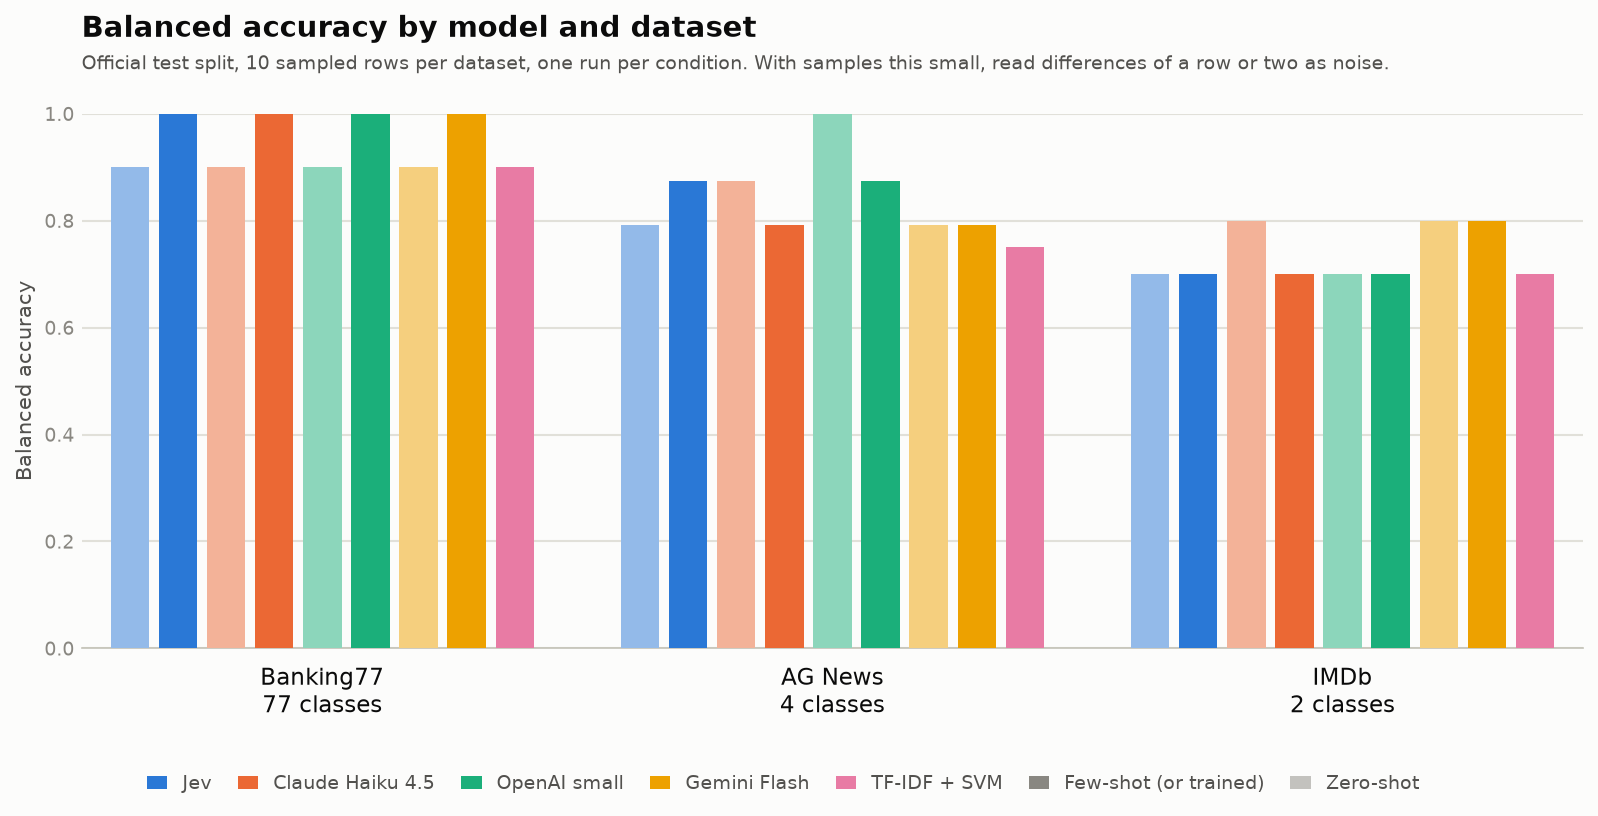

In [12]:
from jev_compare import plots

fig = plots.plot_balanced_accuracy(
    summary,
    DATASETS,
    {ds: len(DATA[ds]["labels"].labels) for ds in DATASETS},
    path=RESULTS / "balanced_accuracy.png",
)

In [ ]:
counts = summary.assign(failed=summary.n_failed_model * 100 + summary.n_failed_infra)
print("Failures per condition (model behaviour / infrastructure):")
display(show(counts, "raw", "failed", lambda v: f"{int(v) // 100} / {int(v) % 100}"))
print("Balanced accuracy with every failed row counted as wrong:")
show(summary, "raw", "bal_acc_fail_wrong", lambda v: f"{v:.2f}")

**Paired comparisons.** Every model classifies the same rows, so two models can be compared row by
row, which is tighter than comparing their separate intervals. The fixed list is: Jev against each
LLM in the same shot condition, Jev against the SVM, and few-shot against zero-shot for each API
model. Each comparison uses only the rows that both sides answered (`n_rows`). `diff` is the first
balanced accuracy minus the second, with a 95% paired bootstrap interval. `interval_excludes_zero`
marks a difference that the sampled rows support. With this many comparisons, an isolated one that
excludes zero is weak evidence.

In [ ]:
svm_frames = {ds: pd.read_csv(RESULTS / f"results_svm_{ds}.csv") for ds in DATASETS}
paired = bench.paired_comparisons(RUNS, svm_frames, DATASETS)
paired.to_csv(RESULTS / "paired_comparisons.csv", index=False)
paired.round(3)

## 7. IMDb with a fitted threshold

A binary classifier can be tuned by moving its decision threshold. Here the score is the probability
of `positive`. For Jev this is its probability for that label. For an LLM it is the reported
`confidence` if the label is `positive`, and one minus the confidence otherwise. The threshold that
gives the best balanced accuracy on the train carve-out is applied to the test sample. The SVM keeps
its own decision boundary, and Banking77 and AG News are raw only.

Read this section as illustrative. The LLM scores take only a few distinct values, so the best
threshold is not well defined and moves with small changes in the carve-out. Jev's probability and
an LLM's stated confidence are different quantities, so the thresholds are not comparable across
model families. The interval for the adjusted score covers the sampled test rows only, not the
uncertainty in the threshold.

In [ ]:
adjusted = []
for model in ACTIVE:
    for shot in SHOTS:
        carve_df = RUNS[("imdb", model, shot, "threshold")]
        test_df = RUNS[("imdb", model, shot, "test")]
        if (carve_df.status == "ok").sum() == 0:
            continue
        t = bench.fit_threshold(carve_df)
        scored = bench.score_frame(bench.apply_threshold(test_df, t), pred_col="pred_adjusted")
        adjusted.append(
            {
                "dataset": "imdb",
                "model": model,
                "model_id": ACTIVE[model]["model_id"],
                "shot": shot,
                "panel": "adjusted",
                "threshold": t,
                "carveout_bal_acc_raw": bench.score_frame(carve_df)["bal_acc"],
                **scored,
            }
        )
summary = pd.concat([summary, pd.DataFrame(adjusted)], ignore_index=True)
summary.to_csv(RESULTS / "summary.csv", index=False)

if adjusted:
    idx = ["model", "shot"]
    adj = summary[summary.panel == "adjusted"].set_index(idx)
    raw = summary[(summary.panel == "raw") & (summary.dataset == "imdb")].set_index(idx)
    pd.DataFrame(
        {
            "threshold": adj.threshold,
            "carve-out, raw": adj.carveout_bal_acc_raw,
            "test, raw": raw.bal_acc.reindex(adj.index),
            "test, adjusted": adj.bal_acc,
            "adjusted, lower": adj.bal_acc_lo,
            "adjusted, upper": adj.bal_acc_hi,
        }
    ).round(2)
else:
    print("No API model ran on IMDb, so there is no threshold to fit.")

## 8. Cost and latency

Cost per 1,000 rows is worked out from the tokens actually used, for the rows that got an answer.
Tokens of failed attempts are not known, so retries add cost that is not counted. For the LLMs it
uses list prices from `configs/models.json` (each with its source), with cached tokens at the
provider's cache price. Anthropic charges extra to write to its cache, and Gemini's cache creation is
billed as normal input (storage, a fraction of a cent, is left out). `cached_share` is the share of
input tokens served from a cache, and `cost_usd_per_1k_rows_no_cache` prices the same calls with no
caching, to show the saving. For Jev the cost is the gateway's `marketCost` field, which is the list
price, because the gateway charged nothing on this account, and Jev has no caching.

`latency_*` is per call, from the successful attempt only. `wall_*` is per row from the first
attempt to the answer, so it includes failed attempts and the waits between them. For Jev it also includes the wait
for the request pacer (section 1), so it shows the account's rate limit, not Jev's speed. `retry_rate` is
the share of rows that needed more than one attempt, and `run_wall_s` is the time for the whole
condition with `WORKERS` requests in flight. Jev goes through the Vercel AI Gateway and the LLMs are
called directly, so latency also reflects the route. The SVM has no per-call price. Its cost is the
one-off training time shown below and a marginal inference cost close to zero.

In [ ]:
cost_rows = []
for (ds, model, shot, split), df in RUNS.items():
    if split == "test":
        cost_rows.append(
            {
                "dataset": ds,
                "model": model,
                "shot": shot,
                "run_wall_s": ELAPSED[(ds, model, shot, split)],
                **bench.cost_latency(df, ACTIVE[model]),
            }
        )
cost = pd.DataFrame(cost_rows)
svm_cost = pd.DataFrame(
    [
        {
            "dataset": ds,
            "model": "svm",
            "shot": "trained",
            "cost_usd_per_1k_rows": 0.0,
            "fit_time_s": s["fit_time_s"],
            "predict_ms_per_row": s["predict_ms_per_row"],
        }
        for ds, s in SVM.items()
    ]
)
pd.concat([cost, svm_cost], ignore_index=True).to_csv(RESULTS / "cost_latency.csv", index=False)

api = cost.copy()
api["model"] = pd.Categorical(api.model, ORDER, ordered=True)
api = api.sort_values(["dataset", "model", "shot"]).set_index(["dataset", "model", "shot"])
api.round(
    {
        "run_wall_s": 0,
        "input_tokens_per_row": 0,
        "output_tokens_per_row": 0,
        "cached_share": 2,
        "cost_usd_per_1k_rows": 4,
        "cost_usd_per_1k_rows_no_cache": 4,
        "latency_median_s": 2,
        "latency_p95_s": 2,
        "wall_median_s": 2,
        "wall_p95_s": 2,
        "retry_rate": 2,
    }
)

In [ ]:
# SVM: trained once per dataset. Marginal cost per row is close to zero.
svm_table.round(
    {
        "cv_bal_acc": 3,
        "bal_acc_full_test": 3,
        "bal_acc_full_test_lo": 3,
        "bal_acc_full_test_hi": 3,
        "fit_time_s": 1,
        "predict_ms_per_row": 3,
    }
)

In [17]:
used = []
for key, cfg in MODELS.items():
    returned = sorted(
        {
            r
            for (ds, m, s, sp), df in RUNS.items()
            if m == key
            for r in df.model_returned.dropna().unique()
        }
    )
    used.append(
        {
            "model": key,
            "model_id_requested": cfg["model_id"],
            "model_id_returned": "; ".join(returned) or None,
            "ran": key in ACTIVE,
            "not_run_reason": SKIPPED.get(key),
            "run_date": RUN_DATE,
            "params": json.dumps(cfg.get("params", {})),
            "requests_per_minute": cfg.get("requests_per_minute"),
            "input_usd_per_mtok": cfg.get("input_per_mtok"),
            "cached_input_usd_per_mtok": cfg.get("cached_input_per_mtok"),
            "cache_write_usd_per_mtok": cfg.get("cache_write_per_mtok"),
            "output_usd_per_mtok": cfg.get("output_per_mtok"),
            "price_source": cfg.get("price_source"),
        }
    )
used = pd.DataFrame(used)
used.to_csv(RESULTS / "models_used.csv", index=False)
used.set_index("model")

,model_id_requested,model_id_returned,ran,not_run_reason,run_date,params,input_usd_per_mtok,cached_input_usd_per_mtok,cache_write_usd_per_mtok,output_usd_per_mtok,price_source
model,,,,,,,,,,,
jev,typesafe-ai/jev,typesafe-ai/jev,True,None,2026-09-20,{},NaN,NaN,NaN,NaN,NaN
haiku,claude-haiku-4-5,claude-haiku-4-5-20251001,True,None,2026-09-20,"{""extra_body"": {""temperature"": 0}}",1.00,0.100,1.25,5.00,https://platform.claude.com/docs/en/about-claude/pricing
openai,gpt-5.4-mini,gpt-5.4-mini-2026-03-17,True,None,2026-09-20,"{""reasoning"": {""effort"": ""none""}}",0.75,0.075,NaN,4.50,https://developers.openai.com/api/docs/models/gpt-5.4-mini
gemini,gemini-3.8-flash,gemini-3.8-flash,True,None,2026-09-20,"{""temperature"": 0, ""thinking_config"": {""thinking_budget"": 0}}",0.75,0.075,NaN,3.75,https://ai.google.dev/gemini-api/docs/pricing


Jev's response carries no version string, only `typesafe-ai/jev`, so "the Jev that was tested" means
that ID as served on the run date (see `01_jev_mechanics.ipynb`).

## 9. Files and how to read the results

Written to `results/`: `sample_<dataset>.csv`, `fewshot_<dataset>.csv`, `threshold_carveout_imdb.csv`,
`results_<model>_<shot>_<dataset>.jsonl` (with `_threshold` variants for the IMDb carve-out),
`results_svm_<dataset>.csv`, `summary.csv`, `paired_comparisons.csv`, `cost_latency.csv`,
`models_used.csv`, `run_manifest.json` and `balanced_accuracy.png`.

How far to trust the tables:

- Use the intervals and the paired comparisons, not the point scores alone. With a small sample one
  row moves a dataset's score by a large step, and differences between models are within noise. The
  full run uses 1,000 rows per dataset. Do not draw conclusions from a smaller `N_TEST`.
- Balanced accuracy averages recall over the classes that appear in the sample. On Banking77 each
  class has about 13 rows, so the score for one class is coarse, and only the average over classes
  is stable.
- Each condition was run once, so run-to-run variation is not measured. The intervals cover the
  choice of test rows only.
- Few-shot results come from one draw of examples per dataset. A different draw could move them.
- The SVM is a small baseline with no tuning beyond `C`. It is not the best classical model, and it
  is trained on all of train, unlike the few-shot models.
- The LLMs answer with a label and a confidence. Label-only output might score differently.
- The IMDb threshold is fitted on a carve-out and is illustrative (section 7).
- The datasets are public and may be in the models' training data.
- Latency compares different routes (the gateway for Jev, direct calls for the LLMs) and includes
  the effect of `WORKERS` requests in flight.
- Cost counts successful attempts only, at list prices.